# BSH Model Coastline

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path

In [ ]:
# Parameters
base_path = "/gxfs_work/geomar/smomw122/2025_fucus-dispersal"

In [3]:
base_path = Path(base_path)
coastline_path = base_path / "data" / "BSH_model_coastline" / "coastline.geojson"
coastline_aw_path = base_path / "data" / "BSH_model_coastline" / "coastline_always_wet.geojson"

gdf = gpd.read_file(coastline_path)
gdf_aw = gpd.read_file(coastline_aw_path)
print(f"All wet:    {len(gdf)} polygons")
print(f"Always wet: {len(gdf_aw)} polygons")

All wet:    8 polygons
Always wet: 24 polygons


In [4]:
def bounds_with_margin(gdf_subset, margin=0.5):
    """Get [lon_min, lon_max, lat_min, lat_max] with margin from geometry bounds."""
    b = gdf_subset.total_bounds  # (minx, miny, maxx, maxy)
    return [b[0] - margin, b[2] + margin, b[1] - margin, b[3] + margin]

def plot_overlay(gdf_all, gdf_aw, extent, title, figsize=(14, 8)):
    """Plot all-wet as filled polygons, always-wet boundary as overlay line."""
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )
    # Filled: all wet
    gdf_all[gdf_all.grid == "coarse"].plot(
        ax=ax, facecolor="lightblue", edgecolor="0.3", linewidth=0.3, transform=ccrs.PlateCarree(),
    )
    gdf_all[gdf_all.grid == "fine"].plot(
        ax=ax, facecolor="lightyellow", edgecolor="0.3", linewidth=0.3, transform=ccrs.PlateCarree(),
    )
    # Line: always wet boundary
    gdf_aw.boundary.plot(
        ax=ax, color="tab:orange", linewidth=0.6, transform=ccrs.PlateCarree(),
    )
    ax.coastlines(color="red", linewidth=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.3)
    ax.set_extent(extent)
    ax.set_title(title)
    plt.show()

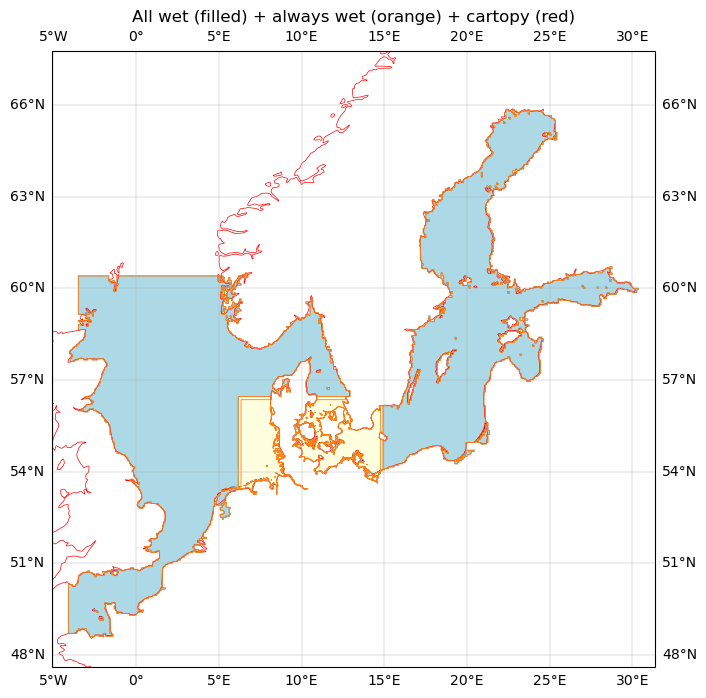

In [5]:
plot_overlay(
    gdf, gdf_aw,
    extent=bounds_with_margin(gdf, margin=1),
    title="All wet (filled) + always wet (orange) + cartopy (red)",
)

## Sometimes-wet cells (tidal flats)

Cells in the full coastline but not in the always-wet coastline (H0 <= 0).

In [6]:
import shapely

# {full} \ {always wet} per grid
sometimes_wet = []
for grid in ["fine", "coarse"]:
    full_union = shapely.unary_union(gdf[gdf.grid == grid].geometry)
    aw_union = shapely.unary_union(gdf_aw[gdf_aw.grid == grid].geometry)
    diff = full_union.difference(aw_union)
    if diff.is_empty:
        continue
    for geom in getattr(diff, "geoms", [diff]):
        sometimes_wet.append({"grid": grid, "geometry": geom})

gdf_sw = gpd.GeoDataFrame(sometimes_wet, crs="EPSG:4326")
print(f"Sometimes-wet polygons: {len(gdf_sw)} ({gdf_sw.grid.value_counts().to_dict()})")

Sometimes-wet polygons: 988 ({'fine': 982, 'coarse': 6})


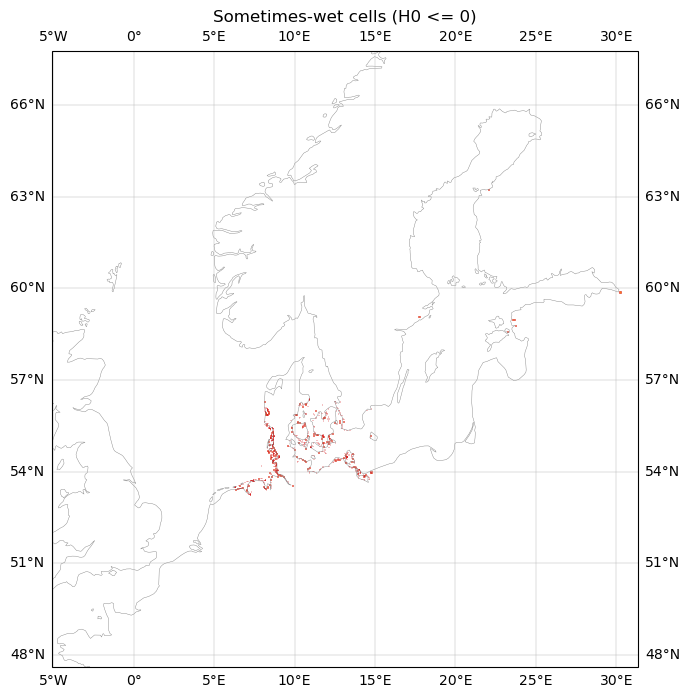

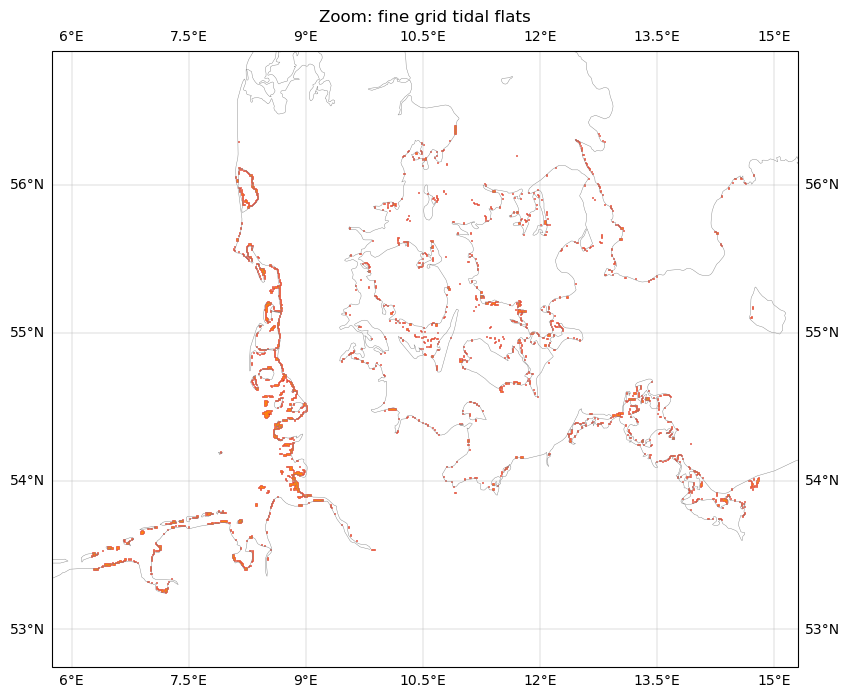

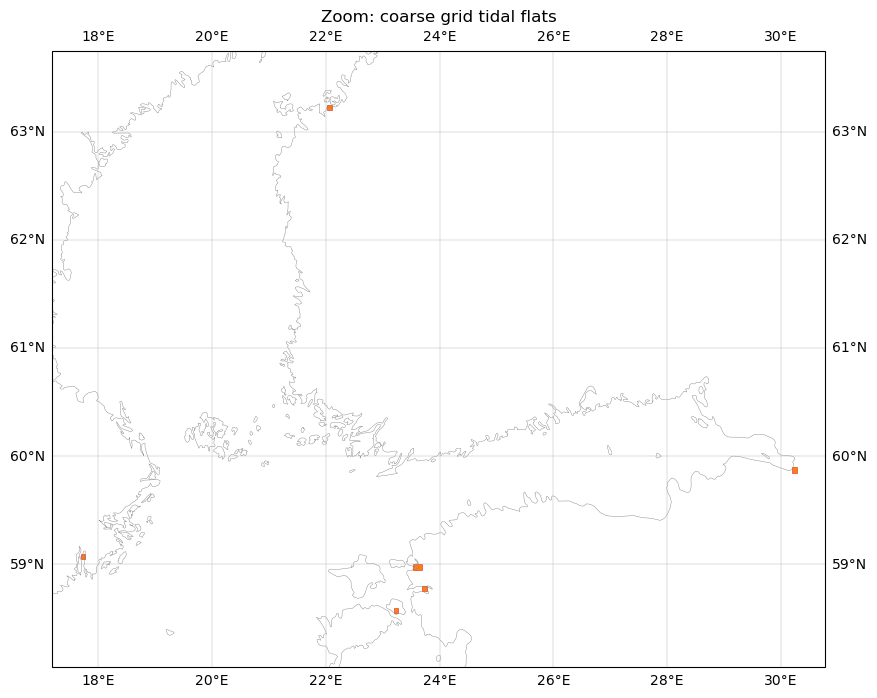

In [7]:
def plot_sometimes_wet(gdf_sw, extent, title, figsize=(14, 8)):
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )
    gdf_sw.plot(
        ax=ax, facecolor="tab:orange", edgecolor="tab:red", linewidth=0.4,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(color="0.5", linewidth=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.3)
    ax.set_extent(extent)
    ax.set_title(title)
    plt.show()

# Full extent
plot_sometimes_wet(
    gdf_sw, extent=bounds_with_margin(gdf, margin=1),
    title="Sometimes-wet cells (H0 <= 0)",
)

# Zoom: fine grid tidal flats
plot_sometimes_wet(
    gdf_sw,
    extent=bounds_with_margin(gdf_sw[gdf_sw.grid == "fine"]),
    title="Zoom: fine grid tidal flats",
)

# Zoom: coarse grid tidal flats
plot_sometimes_wet(
    gdf_sw,
    extent=bounds_with_margin(gdf_sw[gdf_sw.grid == "coarse"]),
    title="Zoom: coarse grid tidal flats",
)